# Transfer Attack (Transferability) Robustness Demo — GNN Fraud Detection

This notebook evaluates **transfer attacks** on our GNN fraud detectors:
1) craft adversarial feature perturbations on a **surrogate** model (e.g., GCN),  
2) test how well the same perturbations **transfer** to other models (GAT, GraphSAGE).

> **Expected input:** your processed dataset file `data.pt` (Elliptic) placed at `data/processed/elliptic/data.pt` inside the repo.  
If it's missing, the notebook will ask you to upload it.

**Tip for a 5-minute demo:** run cells top→bottom; the main plot is **ASR vs ε** (transferability curve).

In [27]:
#@title 1) Configuration (edit if needed)

# Repo options:
REPO_MODE = "upload_zip"  #@param ["upload_zip", "git_clone"]
REPO_ZIP_NAME = "gnn-adversarial-blockchain-colab.zip"  #@param {type:"string"}
REPO_URL = ""  #@param {type:"string"}

# Name of the folder created after unzip/clone:
REPO_DIRNAME = "gnn-adversarial-blockchain-gpt"  #@param {type:"string"}

# Dataset location (relative to repo root):
DATA_PT_REL = "data/processed/elliptic/data.pt"

# Checkpoints live here (relative to repo root):
MODELS_DIR_REL = "models"

# Transfer-attack demo settings:
SURROGATE = "gat"  #@param ["gcn", "gat", "graphsage"]
ATTACK = "fgsm"  #@param ["fgsm", "pgd"]

# Budgets (epsilon for L_inf feature perturbations):
EPS_LIST = [0.0, 0.002, 0.005, 0.01, 0.02]  # keep short for demo

# How many test nodes to attack (subset for speed):
N_ATTACK = 50  #@param {type:"integer"}

# PGD params (only used if ATTACK="pgd"):
PGD_STEPS = 10  #@param {type:"integer"}
PGD_ALPHA = 0.05  #@param {type:"number"}

# Random seed:
SEED = 0


In [2]:
#@title 2) Load repo into Colab

import os, sys, shutil, zipfile, pathlib, subprocess
from pathlib import Path

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except Exception:
        return False

if not in_colab():
    raise RuntimeError("This notebook is designed for Google Colab. Please open it in Colab.")

from google.colab import files  # type: ignore

ROOT = Path.cwd()

if REPO_MODE == "upload_zip":
    # Upload zip if not present
    if not (ROOT / REPO_ZIP_NAME).exists():
        print(f"Upload your repo zip named: {REPO_ZIP_NAME}")
        up = files.upload()
        assert REPO_ZIP_NAME in up, f"Upload a file named {REPO_ZIP_NAME}"

    # Unzip
    if (ROOT / REPO_DIRNAME).exists():
        print("Repo folder already exists:", ROOT / REPO_DIRNAME)
    else:
        with zipfile.ZipFile(ROOT / REPO_ZIP_NAME, "r") as zf:
            zf.extractall(ROOT)
        print("Unzipped to:", ROOT / REPO_DIRNAME)

elif REPO_MODE == "git_clone":
    assert REPO_URL.strip(), "Set REPO_URL for git_clone mode"
    if (ROOT / REPO_DIRNAME).exists():
        print("Repo folder already exists:", ROOT / REPO_DIRNAME)
    else:
        subprocess.check_call(["git", "clone", REPO_URL, REPO_DIRNAME])

REPO_ROOT = (ROOT / REPO_DIRNAME).resolve()
assert REPO_ROOT.exists(), f"Repo root not found: {REPO_ROOT}"
print("REPO_ROOT =", REPO_ROOT)

# Make imports work
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


Unzipped to: /content/gnn-adversarial-blockchain-gpt
REPO_ROOT = /content/gnn-adversarial-blockchain-gpt


In [3]:
#@title 3) Install PyG (fast, avoids long builds)

# ✅ For a 5-min demo, you usually do NOT need to reinstall numpy/pandas/sklearn/matplotlib in Colab.
# This cell installs PyTorch Geometric in the fastest safe way.
#
# If you later hit a runtime error about missing `torch_scatter/torch_sparse/...`,
# set INSTALL_PYG_EXT = True and re-run this cell.

INSTALL_PYG_EXT = False  #@param {type:"boolean"}

import sys, subprocess, importlib, torch

def pip_install(args):
    cmd = [sys.executable, "-m", "pip", "install"] + args
    print(" ".join(cmd))
    subprocess.check_call(cmd)

print("torch =", torch.__version__, "| cuda =", torch.version.cuda)

# 1) Install torch-geometric (PyG core). PyG docs: from v2.3+ it can work without extra libs.
try:
    import torch_geometric
    print("torch_geometric already installed:", torch_geometric.__version__)
except Exception:
    pip_install(["-U", "torch-geometric"])

# 2) Optional: install compiled extension wheels (faster ops; sometimes required by older PyG)
if INSTALL_PYG_EXT:
    tv = torch.__version__.split("+")[0]
    cuda = torch.version.cuda
    if cuda is None:
        whl = f"https://data.pyg.org/whl/torch-{tv}+cpu.html"
    else:
        whl = f"https://data.pyg.org/whl/torch-{tv}+cu{cuda.replace('.', '')}.html"
    print("PyG wheel index:", whl)
    # Use normalized package names (pip normalizes '_' and '-' but we keep canonical names)
    pip_install([
        "-U",
        "pyg-lib",
        "torch-scatter",
        "torch-sparse",
        "torch-cluster",
        "torch-spline-conv",
        "-f", whl
    ])

# Final sanity import
import torch_geometric
print("✓ Ready. torch_geometric =", torch_geometric.__version__)


torch = 2.9.0+cu126 | cuda = 12.6
/usr/bin/python3 -m pip install -U torch-geometric
✓ Ready. torch_geometric = 2.7.0


In [4]:
#@title 4) Load data.pt (upload if missing)

from pathlib import Path
from google.colab import files  # type: ignore
import shutil
import torch

data_pt = (REPO_ROOT / DATA_PT_REL).resolve()
if not data_pt.exists():
    print("Missing:", data_pt)
    print("Upload a file named 'data.pt' now (Elliptic processed dataset).")
    up = files.upload()
    assert "data.pt" in up, "Upload a file named exactly: data.pt"
    data_pt.parent.mkdir(parents=True, exist_ok=True)
    shutil.move("data.pt", str(data_pt))
    print("Saved:", data_pt)
else:
    print("Found:", data_pt)

# Load via project's dataset wrapper
from src.datasets.elliptic import EllipticDataset

ds = EllipticDataset(root=str(data_pt.parent))
data = ds.get_data()

print(data)
print("x:", tuple(data.x.shape), "edge_index:", tuple(data.edge_index.shape), "y:", tuple(data.y.shape))
print("Labels:", torch.unique(data.y))
print("train_mask:", hasattr(data, "train_mask"), "test_mask:", hasattr(data, "test_mask"))


Found: /content/gnn-adversarial-blockchain-gpt/data/processed/elliptic/data.pt
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])
x: (203769, 165) edge_index: (2, 234355) y: (203769,)
Labels: tensor([-1,  0,  1])
train_mask: True test_mask: True


In [31]:
#@title 5) Utilities: device, seeds, checkpoint loading

import os, re, json
from pathlib import Path
import numpy as np
import torch

def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

def latest_run_dir(models_root: Path, prefix: str) -> Path | None:
    # Example: models/gcn_20260120_124333/
    cand = sorted([p for p in models_root.glob(f"{prefix}_*") if p.is_dir()])
    return cand[-1] if cand else None

def load_config(run_dir: Path) -> dict:
    cfg_path = run_dir / "config.json"
    if cfg_path.exists():
        return json.loads(cfg_path.read_text())
    return {}

def load_state(run_dir: Path) -> dict:
    ckpt = run_dir / "model.pt"
    assert ckpt.exists(), f"Missing checkpoint: {ckpt}"
    return torch.load(ckpt, map_location="cpu")

def build_model(name: str, cfg: dict, in_dim: int) -> torch.nn.Module:
    name = name.lower()
    if name == "gcn":
        from src.models.gcn import GCN
        mcfg = cfg.get("model", {})
        return GCN(
            in_dim=in_dim,
            hidden_dim=int(mcfg.get("hidden_dim", 128)),
            out_dim=int(mcfg.get("out_dim", 2)),
            num_layers=int(mcfg.get("num_layers", 2)),
            dropout=float(mcfg.get("dropout", 0.5)),
            use_norm=bool(mcfg.get("use_norm", True)),
        )
    if name == "gat":
        from src.models.gat import GAT
        mcfg = cfg.get("model", {})
        return GAT(
            in_dim=in_dim,
            hidden_dim=int(mcfg.get("hidden_dim", 128)),
            out_dim=int(mcfg.get("out_dim", 2)),
            num_layers=int(mcfg.get("num_layers", 2)),
            heads=int(mcfg.get("heads", 4)),
            dropout=float(mcfg.get("dropout", 0.6)),
            use_norm=bool(mcfg.get("use_norm", True)),
        )
    if name == "graphsage":
        from src.models.graphsage import GraphSAGE
        mcfg = cfg.get("model", {})
        return GraphSAGE(
            in_dim=in_dim,
            hid_dim=int(mcfg.get("hidden_dim", 128)),
            out_dim=int(mcfg.get("out_dim", 2)),
            aggr=str(mcfg.get("aggr", "mean")),
        )
    raise ValueError(f"Unknown model name: {name}")

MODELS_ROOT = (REPO_ROOT / MODELS_DIR_REL).resolve()
assert MODELS_ROOT.exists(), f"Missing models dir: {MODELS_ROOT}"

# Load models (latest run for each)
model_names = ["gcn", "gat", "graphsage"]
models = {}
configs = {}

for mn in model_names:
    run_dir = latest_run_dir(MODELS_ROOT, mn)
    if run_dir is None:
        print(f"⚠️ No checkpoint folder found for {mn} under {MODELS_ROOT}. Skipping.")
        continue

    cfg = load_config(run_dir)
    sd = load_state(run_dir)

    model = build_model(mn, cfg, in_dim=data.x.size(1))

    # Support either a raw state_dict or a wrapper dict containing one.
    state = sd["state_dict"] if isinstance(sd, dict) and "state_dict" in sd else sd

    try:
        model.load_state_dict(state, strict=True)
    except Exception as e:
        inc = model.load_state_dict(state, strict=False)
        print(f"⚠️ Non-strict checkpoint load for {mn}: {e}")
        if hasattr(inc, "missing_keys") and (inc.missing_keys or inc.unexpected_keys):
            print("  missing_keys:", inc.missing_keys)
            print("  unexpected_keys:", inc.unexpected_keys)

    model = model.to(device).eval()
    models[mn] = model
    configs[mn] = cfg
    print(f"Loaded {mn} from {run_dir.name}")

assert len(models) > 0, f"No models were loaded. Check checkpoints under: {MODELS_ROOT}"



Loaded gcn from gcn_20260120_124333
Loaded gat from gat_20260120_085650
Loaded graphsage from graphsage_20260120_085711


,model,acc,f1_pos,f1_macro,roc_auc,fraud_pred,n_test_labeled
1,gat,0.967651,0.591429,0.787294,0.876086,292,8841
0,gcn,0.958602,0.487395,0.732912,0.818322,306,8841
2,graphsage,0.969460,0.575472,0.779816,0.848043,228,8841


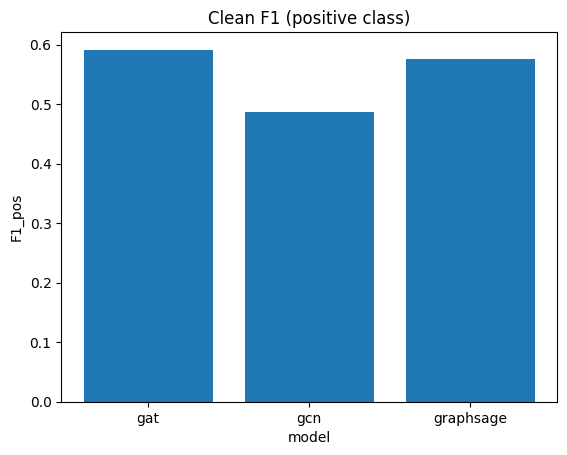

In [32]:
#@title 6) Clean evaluation + quick baseline plots

import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.training.metrics import get_split_mask, evaluate_logits_on_split, roc_auc_binary

test_mask = get_split_mask(data, "test").to(device)

assert len(models) > 0, "No models loaded; run cell 5 first and check checkpoints."

rows = []
with torch.no_grad():
    for mn, model in models.items():
        logits = model(data.x, data.edge_index)
        sm = evaluate_logits_on_split(logits, data.y, test_mask, split="test")
        auc = roc_auc_binary(logits, data.y, test_mask)
        rows.append({
            "model": mn,
            "acc": sm.acc,
            "f1_pos": sm.f1_pos,
            "f1_macro": sm.f1_macro,
            "roc_auc": auc,
            "fraud_pred": sm.fraud_predictions,
            "n_test_labeled": sm.n_labeled,
        })

df_clean = pd.DataFrame(rows)
if df_clean.empty:
    raise RuntimeError("Clean evaluation produced empty results. Check that models dict is non-empty and that test_mask has labeled nodes.")
df_clean = df_clean.sort_values("model")
display(df_clean)

# Bar plot: F1(pos) clean
plt.figure()
plt.bar(df_clean["model"], df_clean["f1_pos"])
plt.title("Clean F1 (positive class)")
plt.xlabel("model")
plt.ylabel("F1_pos")
plt.show()


## Transfer-attack evaluation

We craft adversarial features `x_adv` on the **surrogate** model, then evaluate every **victim** model on the same `x_adv`.
- **FGSM:** single-step sign gradient
- **PGD (L∞):** multi-step stronger attack

We report:
- **ASR_pos / ASR_neg** (attack success rate on *clean-correct* nodes, restricted to attacked nodes)
- **F1_pos drop / F1_macro drop**
- **ROC-AUC drop**
- **Mean confidence drop** (true-class probability decrease)

In [33]:
#@title 7) Run transfer attack sweep (fast)

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.training.metrics import (
    get_split_mask,
    evaluate_logits_on_split,
    roc_auc_binary,
    asr_pos_neg,
    mean_confidence_drop,
)

# Attack implementations
from src.attacks.fgsm import FGSMAttack
from src.attacks.pgd import PGDAttack

# 1) pick attack nodes from test split (labeled only)
test_mask = get_split_mask(data, "test").to(device)
labeled_test_idx = torch.where(test_mask & (data.y != -1))[0]
if labeled_test_idx.numel() == 0:
    raise RuntimeError("No labeled test nodes found. Check your preprocessing/masks.")

# sample for speed
n = min(int(N_ATTACK), int(labeled_test_idx.numel()))
perm = torch.randperm(labeled_test_idx.numel(), device=device)[:n]
attack_nodes = labeled_test_idx[perm].detach()

attack_mask = torch.zeros(data.num_nodes, dtype=torch.bool, device=device)
attack_mask[attack_nodes] = True

# Clamp to observed feature range to avoid exploding values
x_min = float(data.x.min().item())
x_max = float(data.x.max().item())
clamp = (x_min, x_max)

surrogate_model = models[SURROGATE]

# 2) build attacker on surrogate
if ATTACK == "fgsm":
    attacker = FGSMAttack(surrogate_model, data, device=device, clamp=clamp)
elif ATTACK == "pgd":
    attacker = PGDAttack(surrogate_model, data, device=device, clamp=clamp)
else:
    raise ValueError("ATTACK must be fgsm or pgd")

# 3) sweep eps and evaluate transfer on all victims
results = []
with torch.no_grad():
    logits_clean_all = {mn: m(data.x, data.edge_index) for mn, m in models.items()}

for eps in EPS_LIST:
    # craft x_adv ON SURROGATE (no_grad must be off here)
    if eps == 0.0:
        x_adv = data.x.detach()
    else:
        if ATTACK == "fgsm":
            x_adv = attacker.attack(attack_nodes, eps=float(eps), targeted=False)
        else:
            x_adv = attacker.attack(
                attack_nodes, eps=float(eps),
                alpha=float(PGD_ALPHA), steps=int(PGD_STEPS),
                targeted=False
            )

    with torch.no_grad():
        for victim_name, victim_model in models.items():
            logits_clean = logits_clean_all[victim_name]
            logits_adv = victim_model(x_adv, data.edge_index)

            # Split-level metrics (whole test split)
            sm_clean = evaluate_logits_on_split(logits_clean, data.y, test_mask, "test")
            sm_adv = evaluate_logits_on_split(logits_adv, data.y, test_mask, "test")

            auc_clean = roc_auc_binary(logits_clean, data.y, test_mask)
            auc_adv = roc_auc_binary(logits_adv, data.y, test_mask)

            # Attack-focused metrics (ONLY attacked nodes)
            asr_pos, succ_pos, att_pos, asr_neg, succ_neg, att_neg = asr_pos_neg(
                data.y, logits_clean, logits_adv, attack_mask, pos_label=1
            )
            conf_drop, n_used = mean_confidence_drop(
                data.y, logits_clean, logits_adv, attack_mask, only_clean_correct=True
            )

            results.append({
                "eps": float(eps),
                "surrogate": SURROGATE,
                "victim": victim_name,
                "attack": ATTACK,
                "n_attacked": int(attack_nodes.numel()),
                "asr_pos": float(asr_pos),
                "asr_neg": float(asr_neg),
                "succ_pos": int(succ_pos),
                "att_pos": int(att_pos),
                "succ_neg": int(succ_neg),
                "att_neg": int(att_neg),
                "mean_conf_drop": float(conf_drop),
                "n_conf_drop_used": int(n_used),
                "acc_clean": float(sm_clean.acc),
                "acc_adv": float(sm_adv.acc),
                "f1_pos_clean": float(sm_clean.f1_pos),
                "f1_pos_adv": float(sm_adv.f1_pos),
                "f1_macro_clean": float(sm_clean.f1_macro),
                "f1_macro_adv": float(sm_adv.f1_macro),
                "roc_auc_clean": float(auc_clean),
                "roc_auc_adv": float(auc_adv),
                "f1_pos_drop": float(sm_clean.f1_pos - sm_adv.f1_pos),
                "f1_macro_drop": float(sm_clean.f1_macro - sm_adv.f1_macro),
                "roc_auc_drop": float(auc_clean - auc_adv) if (not np.isnan(auc_clean) and not np.isnan(auc_adv)) else float("nan"),
            })

df = pd.DataFrame(results)
display(df.head())

# Show summary for the largest eps
eps_max = max(EPS_LIST)
print("\nSummary at eps =", eps_max)
display(df[df["eps"] == eps_max][["victim","asr_pos","asr_neg","f1_pos_drop","f1_macro_drop","roc_auc_drop","mean_conf_drop"]].sort_values("victim"))


,eps,surrogate,victim,attack,n_attacked,asr_pos,asr_neg,succ_pos,att_pos,succ_neg,...,acc_adv,f1_pos_clean,f1_pos_adv,f1_macro_clean,f1_macro_adv,roc_auc_clean,roc_auc_adv,f1_pos_drop,f1_macro_drop,roc_auc_drop
0,0.000,gat,gcn,fgsm,50,0.0,0.0,0,1,0,...,0.958602,0.487395,0.487395,0.732912,0.732912,0.818322,0.818322,0.0,0.0,0.000000
1,0.000,gat,gat,fgsm,50,0.0,0.0,0,2,0,...,0.967651,0.591429,0.591429,0.787294,0.787294,0.876086,0.876086,0.0,0.0,0.000000
2,0.000,gat,graphsage,fgsm,50,0.0,0.0,0,1,0,...,0.969460,0.575472,0.575472,0.779816,0.779816,0.848043,0.848043,0.0,0.0,0.000000
3,0.002,gat,gcn,fgsm,50,0.0,0.0,0,1,0,...,0.958602,0.487395,0.487395,0.732912,0.732912,0.818322,0.818240,0.0,0.0,0.000083
4,0.002,gat,gat,fgsm,50,0.0,0.0,0,2,0,...,0.967651,0.591429,0.591429,0.787294,0.787294,0.876086,0.875925,0.0,0.0,0.000161



Summary at eps = 0.02


,victim,asr_pos,asr_neg,f1_pos_drop,f1_macro_drop,roc_auc_drop,mean_conf_drop
13,gat,0.5,0.0,0.002015,0.001037,0.001701,0.023616
12,gcn,0.0,0.0,0.000000,0.000000,0.000881,0.007910
14,graphsage,0.0,0.0,0.000000,0.000000,0.000420,0.006960


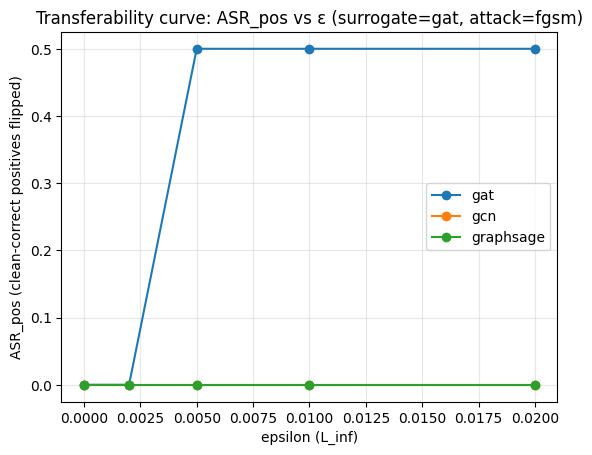

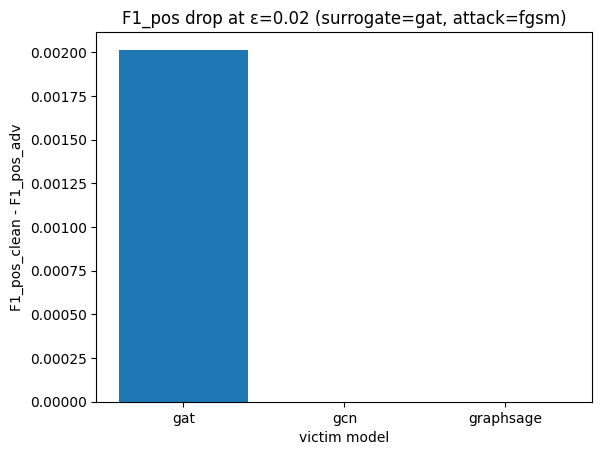

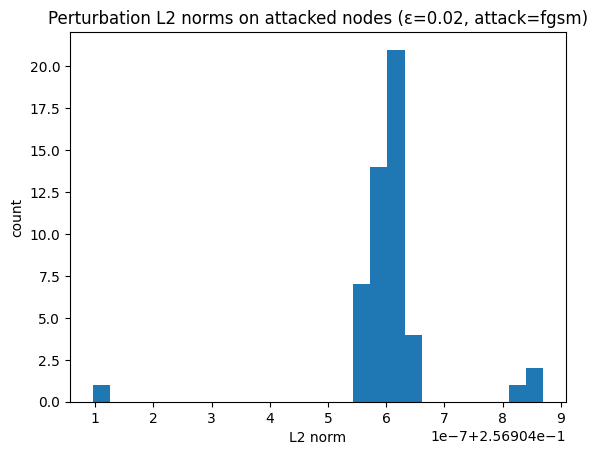

In [34]:
#@title 8) Visualizations: transfer ASR curves + F1 drop bars + perturbation histogram

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# 1) ASR_pos vs eps for each victim
plt.figure()
for victim in sorted(df["victim"].unique()):
    d = df[df["victim"] == victim].sort_values("eps")
    plt.plot(d["eps"], d["asr_pos"], marker="o", label=victim)
plt.title(f"Transferability curve: ASR_pos vs ε (surrogate={SURROGATE}, attack={ATTACK})")
plt.xlabel("epsilon (L_inf)")
plt.ylabel("ASR_pos (clean-correct positives flipped)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2) F1_pos drop at max eps
eps_max = max(EPS_LIST)
dmax = df[df["eps"] == eps_max].sort_values("victim")
plt.figure()
plt.bar(dmax["victim"], dmax["f1_pos_drop"])
plt.title(f"F1_pos drop at ε={eps_max} (surrogate={SURROGATE}, attack={ATTACK})")
plt.xlabel("victim model")
plt.ylabel("F1_pos_clean - F1_pos_adv")
plt.show()

# 3) Histogram of L2 perturbation norms on attacked nodes (for the strongest eps)
# Recompute x_adv for eps_max to get delta distribution
x_clean = data.x.detach()
if eps_max == 0.0:
    x_adv_max = x_clean
else:
    if ATTACK == "fgsm":
        x_adv_max = attacker.attack(attack_nodes, eps=float(eps_max), targeted=False)
    else:
        x_adv_max = attacker.attack(
            attack_nodes, eps=float(eps_max),
            alpha=float(PGD_ALPHA), steps=int(PGD_STEPS),
            targeted=False
        )

delta = (x_adv_max[attack_nodes] - x_clean[attack_nodes]).detach()
l2 = torch.norm(delta, p=2, dim=1).cpu().numpy()

plt.figure()
plt.hist(l2, bins=30)
plt.title(f"Perturbation L2 norms on attacked nodes (ε={eps_max}, attack={ATTACK})")
plt.xlabel("L2 norm")
plt.ylabel("count")
plt.show()


## Optional: full transfer matrix (surrogate × victim) at one ε

This creates a **heatmap** of ASR_pos when each model acts as the surrogate (attack generator) and all models are evaluated as victims.

(Kept short for demo; uses a single ε and the same attacked nodes.)

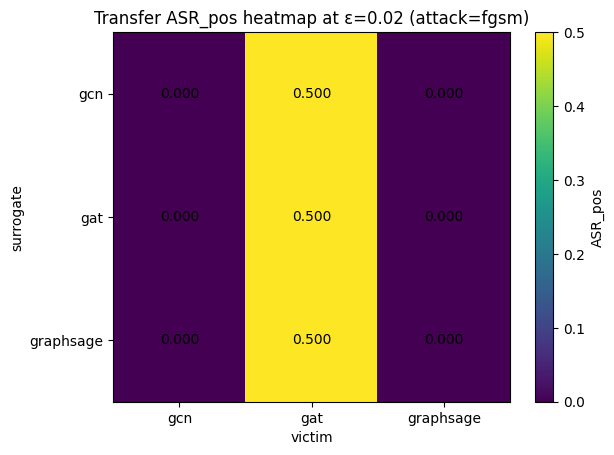

In [35]:
#@title 9) Transfer matrix heatmap (single epsilon)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

eps_matrix = max(EPS_LIST)  # use strongest in the sweep
surrogates = ["gcn", "gat", "graphsage"]
victims = ["gcn", "gat", "graphsage"]

mat = np.zeros((len(surrogates), len(victims)), dtype=float)

# reuse same attack_nodes and masks
for i, s in enumerate(surrogates):
    smodel = models[s]
    if ATTACK == "fgsm":
        s_attacker = FGSMAttack(smodel, data, device=device, clamp=clamp)
        x_adv = s_attacker.attack(attack_nodes, eps=float(eps_matrix), targeted=False) if eps_matrix > 0 else data.x.detach()
    else:
        s_attacker = PGDAttack(smodel, data, device=device, clamp=clamp)
        x_adv = s_attacker.attack(attack_nodes, eps=float(eps_matrix), alpha=float(PGD_ALPHA), steps=int(PGD_STEPS), targeted=False) if eps_matrix > 0 else data.x.detach()

    with torch.no_grad():
        for j, v in enumerate(victims):
            vlogits_clean = logits_clean_all[v]
            vlogits_adv = models[v](x_adv, data.edge_index)
            asr_pos, *_ = asr_pos_neg(data.y, vlogits_clean, vlogits_adv, attack_mask, pos_label=1)
            mat[i, j] = float(asr_pos)

plt.figure()
plt.imshow(mat, aspect="auto")
plt.xticks(range(len(victims)), victims)
plt.yticks(range(len(surrogates)), surrogates)
plt.title(f"Transfer ASR_pos heatmap at ε={eps_matrix} (attack={ATTACK})")
plt.xlabel("victim")
plt.ylabel("surrogate")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        plt.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center")
plt.colorbar(label="ASR_pos")
plt.show()


## Talking points for a 5-minute demo

- **What is transferability?** Attacks crafted on one model can generalize to others (black-box risk).
- **What you show:** ASR_pos vs ε curve + heatmap at one ε.
- **Key interpretation:** if GAT/GraphSAGE drop significantly under adversarial examples crafted on GCN, the system is vulnerable in a realistic black-box setting.
